# Comprehensive Exploratory Data Analysis & Data Quality Audit: Retraction Watch Dataset

## 📌 Executive Summary & Overview
This notebook presents a detailed **Exploratory Data Analysis (EDA)** and **Data Quality Assessment** of the **Retraction Watch Database** (`retraction_watch.csv`).

### Objectives:
1. **Data Integrity & Hygiene Audit**:
   - Check for **null/missing values** across all metadata attributes.
   - Evaluate **duplication rate** (exact row duplicates, duplicate Record IDs, duplicate titles, and DOIs).
2. **Feature Engineering**:
   - Parse retraction and publication dates into datetime formats.
   - Calculate `Time_To_Retraction_Days` (delay between original paper publication and retraction).
   - Extract year metrics (`OriginalYear`, `RetractionYear`).
3. **Exploratory Data Visualization**:
   - Temporal trends of retractions vs original publications over time.
   - Distribution of time-to-retraction (histograms, box plots, median/quartiles).
   - Top retraction reasons (multi-value string extraction).
   - Geographic distribution of retracted papers (top countries).
   - Top journals, publishers, and paywalled article proportions.
4. **Actionable Insights & Conclusions**: Summary of data quality findings and domain insights.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import warnings

# Plotting configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['ytick.labelsize'] = 9.5
plt.rcParams['xtick.labelsize'] = 9.5

def wrap_lbl(label, width=32):
    if not label or pd.isna(label):
        return ""
    s = str(label).replace('/', '/ ').replace('  ', ' ')
    return '\n'.join(textwrap.wrap(s, width=width))

print("Environment configured successfully. Ready for data analysis.")


Environment configured successfully. Ready for data analysis.


## 1. Data Loading & Initial Overview
We begin by loading `retraction_watch.csv`, stripping any empty trailing columns, and inspecting the dimensions, column names, data types, and initial records.


In [6]:
# Load dataset
df = pd.read_csv('retraction_watch.csv')

# Drop completely empty or unnamed trailing columns if present
df = df.loc[:, ~df.columns.str.contains(r'^Unnamed|^:\s*$|^$')]

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("--- Column Data Types & Non-Null Information ---")
df.info()


Dataset Shape: 71,641 rows x 20 columns

--- Column Data Types & Non-Null Information ---
<class 'pandas.DataFrame'>
RangeIndex: 71641 entries, 0 to 71640
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Record ID              71400 non-null  float64
 1   Title                  71400 non-null  str    
 2   Subject                71400 non-null  str    
 3   Institution            71399 non-null  str    
 4   Journal                71400 non-null  str    
 5   Publisher              71400 non-null  str    
 6   Country                71400 non-null  str    
 7   Author                 71400 non-null  str    
 8   URLS                   39477 non-null  str    
 9   ArticleType            71400 non-null  str    
 10  RetractionDate         71400 non-null  str    
 11  RetractionDOI          70916 non-null  str    
 12  RetractionPubMedID     66262 non-null  float64
 13  OriginalPaperDate      7140

In [7]:
# Display first 5 records
df.head()


,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,RetractionDate,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes
0,72066.0,Design of control algorithms for false informa...,(B/T) Computer Science;(SOC) Communications;,"School of Economics and Management, Yanshan Un...",Soft Computing,Springer - Nature Publishing Group,China,Kunpeng Jing,NaN,Research Article;,3/5/2026 0:00,10.1007/s00500-023-08071-6,0.0,4/4/2023 0:00,10.1007/s00500-023-08071-6,0.0,Retraction,Concerns/Issues about Peer Review;Concerns/Iss...,No,NaN
1,72065.0,Assessing the role of artificial intelligence ...,(B/T) Data Science;(SOC) Education;(SOC) Psych...,"School of Music and Dance, Xinyang Normal Univ...",Soft Computing,Springer - Nature Publishing Group,China,Ling Lei;Junfeng Li;Wenrui Li,NaN,Research Article;,10/22/2024 0:00,10.1007/s00500-023-08072-5,0.0,4/4/2023 0:00,10.1007/s00500-023-08072-5,37362257.0,Retraction,Concerns/Issues about Peer Review;Concerns/Iss...,No,NaN
2,72061.0,Trust aware secured energy efficient fuzzy clu...,(B/T) Computer Science;(B/T) Technology;,Department of Computer Science and Engineering...,Soft Computing,Springer - Nature Publishing Group,India,Bhukya Kranthikumar;R Leela Velusamy,NaN,Research Article;,1/10/2026 0:00,10.1007/s00500-023-08098-9,0.0,4/10/2023 0:00,10.1007/s00500-023-08098-9,0.0,Retraction,Concerns/Issues about Peer Review;Concerns/Iss...,No,NaN
3,72060.0,Potential risk assessment of ionic liquids bas...,(B/T) Computer Science;(PHY) Chemistry;,"School of Materials and Chemical Engineering, ...",Soft Computing,Springer - Nature Publishing Group,China,Wenchang Zhuang;Wenyou Zhu,NaN,Research Article;,1/12/2026 0:00,10.1007/s00500-023-08141-9,0.0,4/10/2023 0:00,10.1007/s00500-023-08141-9,0.0,Retraction,Concerns/Issues about Peer Review;Concerns/Iss...,No,NaN
4,72059.0,Evaluating critical thinking of English learne...,(SOC) Education;(SOC) Linguistics;,"School of Foreign Language, Changsha Normal Un...",Soft Computing,Springer - Nature Publishing Group,China,Fengying Peng,NaN,Research Article;,10/25/2024 0:00,10.1007/s00500-023-08127-7,0.0,4/15/2023 0:00,10.1007/s00500-023-08127-7,0.0,Retraction,Concerns/Issues about Peer Review;Concerns/Iss...,No,NaN


In [8]:
df.describe()

,Record ID,RetractionPubMedID,OriginalPaperPubMedID
count,71400.000000,6.626200e+04,6.628000e+04
mean,35995.529860,1.630880e+07,1.450050e+07
std,20725.570723,1.734830e+07,1.544089e+07
min,1.000000,0.000000e+00,0.000000e+00
25%,18068.750000,0.000000e+00,0.000000e+00
50%,35983.500000,0.000000e+00,3.062696e+06
75%,53943.250000,3.575200e+07,3.093669e+07
max,72066.000000,4.246909e+07,4.224590e+07


## 2. Data Quality & Hygiene Assessment
In this section, we thoroughly inspect the dataset for:
1. **Missing (Null) Values**: Quantifying missing metadata per field.
2. **Duplication Audit**: Detecting full row duplicates, duplicate `Record ID`s, duplicate paper titles, and duplicate DOIs.


--- Missing Value Breakdown ---


,Missing Count,Missing Percentage (%)
Notes,51571,71.99
URLS,32164,44.90
RetractionPubMedID,5379,7.51
OriginalPaperPubMedID,5361,7.48
OriginalPaperDOI,2765,3.86
RetractionDOI,725,1.01
Institution,242,0.34
Record ID,241,0.34
Subject,241,0.34
Title,241,0.34


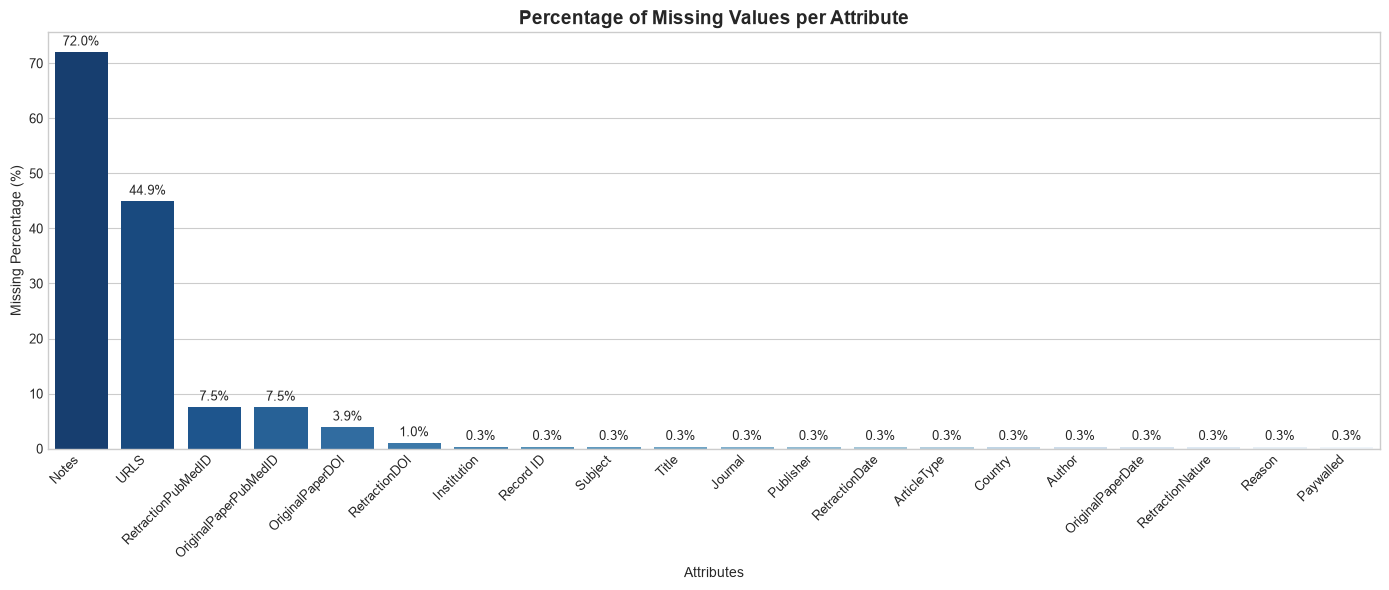

In [ ]:
# Missing values analysis
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing Percentage (%)': null_pct.round(2)
}).sort_values(by='Missing Count', ascending=False)

print("--- Missing Value Breakdown ---")
missing_df

# Visualize Missing Values
plt.figure(figsize=(14, 6))
bars = sns.barplot(x=missing_df.index, y=missing_df['Missing Percentage (%)'], palette='Blues_r')
plt.xticks(rotation=45, ha='right')
plt.title('Percentage of Missing Values per Attribute', fontsize=14, fontweight='bold')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Attributes')
for p in bars.patches:
    if p.get_height() > 0:
        bars.annotate(f'{p.get_height():.1f}%', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
                      textcoords='offset points')
plt.tight_layout()
plt.show()


In [26]:
# Duplication checks
full_dup_count = df.duplicated().sum()
id_dup_count = df.duplicated(subset=['Record ID']).sum() if 'Record ID' in df.columns else 0
title_dup_count = df.duplicated(subset=['Title']).sum() if 'Title' in df.columns else 0
doi_dup_count = df.dropna(subset=['OriginalPaperDOI']).duplicated(subset=['OriginalPaperDOI']).sum() if 'OriginalPaperDOI' in df.columns else 0

dup_summary = pd.DataFrame({
    'Duplication Metric': [
        'Exact Full Row Duplicates', 
        'Duplicate Record IDs', 
        'Duplicate Article Titles', 
        'Duplicate Original Paper DOIs'
    ],
    'Duplicate Count': [full_dup_count, id_dup_count, title_dup_count, doi_dup_count],
    'Percentage (%)': [
        round((full_dup_count / len(df)) * 100, 4),
        round((id_dup_count / len(df)) * 100, 4),
        round((title_dup_count / len(df)) * 100, 4),
        round((doi_dup_count / len(df)) * 100, 4)
    ]
})

print("--- Duplication Analysis Summary ---")
dup_summary


--- Duplication Analysis Summary ---


,Duplication Metric,Duplicate Count,Percentage (%)
0,Exact Full Row Duplicates,240,0.3350
1,Duplicate Record IDs,240,0.3350
2,Duplicate Article Titles,2842,3.9670
3,Duplicate Original Paper DOIs,6297,8.7897


## 3. Feature Engineering & Date Normalization
We parse datetime fields (`RetractionDate`, `OriginalPaperDate`) and engineer key analytical metrics:
- `Time_To_Retraction_Days`: Difference in days between original paper date and retraction date.
- `Time_To_Retraction_Years`: Delay expressed in years.
- `OriginalYear` & `RetractionYear`: Extracted calendar years.


In [27]:
# Convert date columns to datetime
df['RetractionDate_dt'] = pd.to_datetime(df['RetractionDate'], errors='coerce')
df['OriginalPaperDate_dt'] = pd.to_datetime(df['OriginalPaperDate'], errors='coerce')

# Calculate time to retraction in days and years
df['Time_To_Retraction_Days'] = (df['RetractionDate_dt'] - df['OriginalPaperDate_dt']).dt.days
df['Time_To_Retraction_Years'] = df['Time_To_Retraction_Days'] / 365.25

# Extract year features
df['RetractionYear'] = df['RetractionDate_dt'].dt.year
df['OriginalYear'] = df['OriginalPaperDate_dt'].dt.year

# Summary of numerical engineered features
df[['Time_To_Retraction_Days', 'Time_To_Retraction_Years', 'RetractionYear', 'OriginalYear']].describe().round(2)


,Time_To_Retraction_Days,Time_To_Retraction_Years,RetractionYear,OriginalYear
count,71399.00,71399.00,71399.00,71399.00
mean,958.81,2.63,2018.82,2016.24
std,1437.64,3.94,5.95,6.58
min,0.00,0.00,1927.00,1923.00
25%,153.00,0.42,2015.00,2011.00
50%,497.00,1.36,2021.00,2018.00
75%,1124.00,3.08,2023.00,2021.00
max,29622.00,81.10,2026.00,2026.00


## 4. Distribution Analysis: Time to Retraction
How quickly are problematic papers retracted after publication? We examine the distribution of delay times and identify summary statistics (median, interquartile range, outliers).


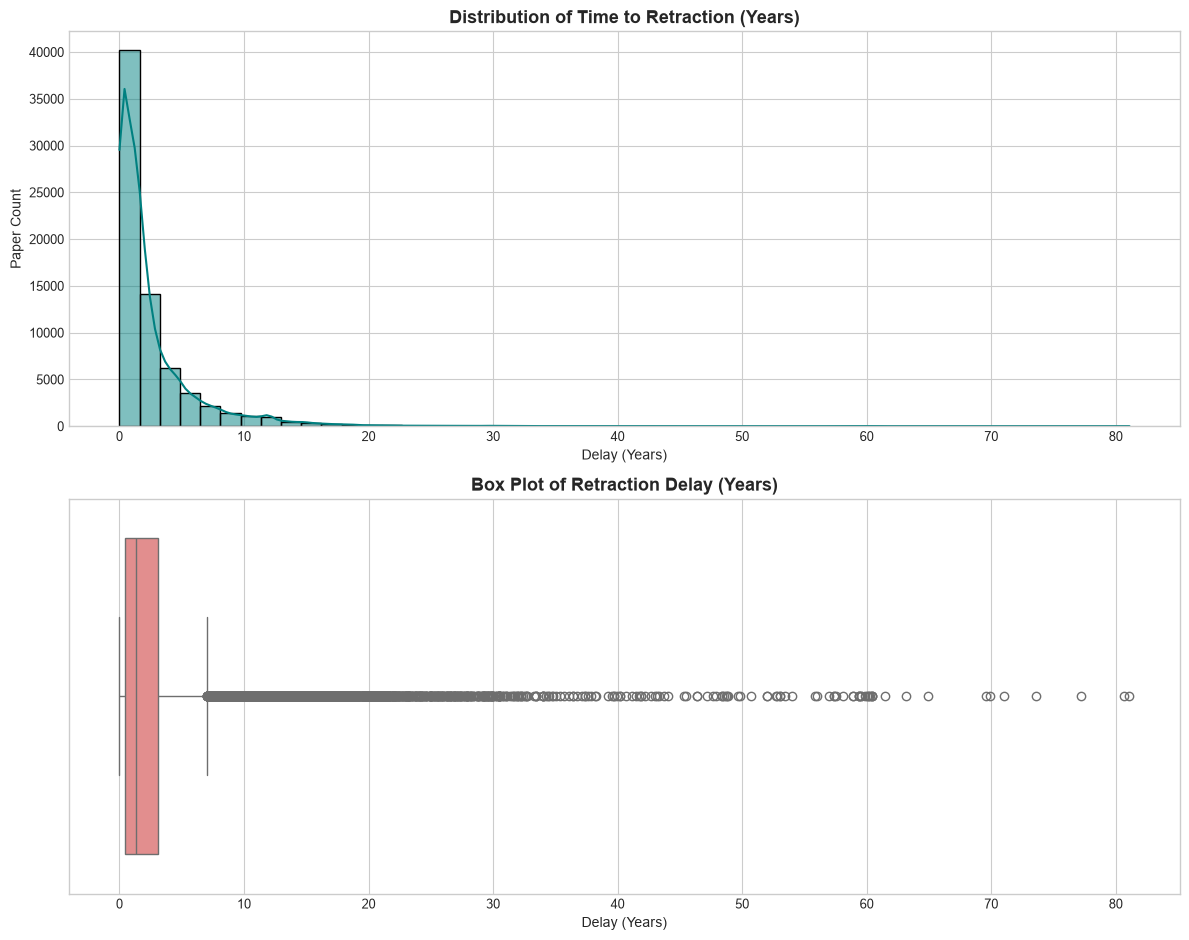

Total Valid Date Pairs Evaluated: 71,399
Median Time to Retraction: 497 days (1.36 years)
Mean Time to Retraction: 959 days (2.63 years)
25th Percentile: 153 days (0.42 years)
75th Percentile: 1124 days (3.08 years)


In [12]:
# Valid delay records (positive days, under 35 years)
valid_delay = df[df['Time_To_Retraction_Days'].notnull() & (df['Time_To_Retraction_Days'] >= 0)]

fig, axes = plt.subplots(2, 1, figsize=(12, 9.5))

# Histogram & KDE
sns.histplot(valid_delay['Time_To_Retraction_Years'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Time to Retraction (Years)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delay (Years)')
axes[0].set_ylabel('Paper Count')

# Box Plot
sns.boxplot(x=valid_delay['Time_To_Retraction_Years'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot of Retraction Delay (Years)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Delay (Years)')

plt.tight_layout()
plt.show()

# Key metrics printout
print(f"Total Valid Date Pairs Evaluated: {len(valid_delay):,}")
print(f"Median Time to Retraction: {valid_delay['Time_To_Retraction_Days'].median():.0f} days ({valid_delay['Time_To_Retraction_Years'].median():.2f} years)")
print(f"Mean Time to Retraction: {valid_delay['Time_To_Retraction_Days'].mean():.0f} days ({valid_delay['Time_To_Retraction_Years'].mean():.2f} years)")
print(f"25th Percentile: {valid_delay['Time_To_Retraction_Days'].quantile(0.25):.0f} days ({valid_delay['Time_To_Retraction_Years'].quantile(0.25):.2f} years)")
print(f"75th Percentile: {valid_delay['Time_To_Retraction_Days'].quantile(0.75):.0f} days ({valid_delay['Time_To_Retraction_Years'].quantile(0.75):.2f} years)")


## 5. Temporal Trends & Comparative Analysis: Publications vs. Retractions Over Time

In this section, we analyze the relationship between **Original Paper Publication Year** and **Retraction Execution Year** using multiple visualization perspectives:
1. **Annual Trajectory Comparison** (Line Chart): Retractions executed vs. original publication volume per year.
2. **Retraction Matrix Heatmap** (2D Heatmap): Interaction matrix showing retractions executed in year $X$ for papers originally published in year $Y$ (2012–2026).
3. **Retraction Delay Cohort Analysis** (Stacked Bar Chart): Distribution of retraction lag categories (<1 yr, 1–3 yrs, 3–5 yrs, >5 yrs) across publication cohorts.


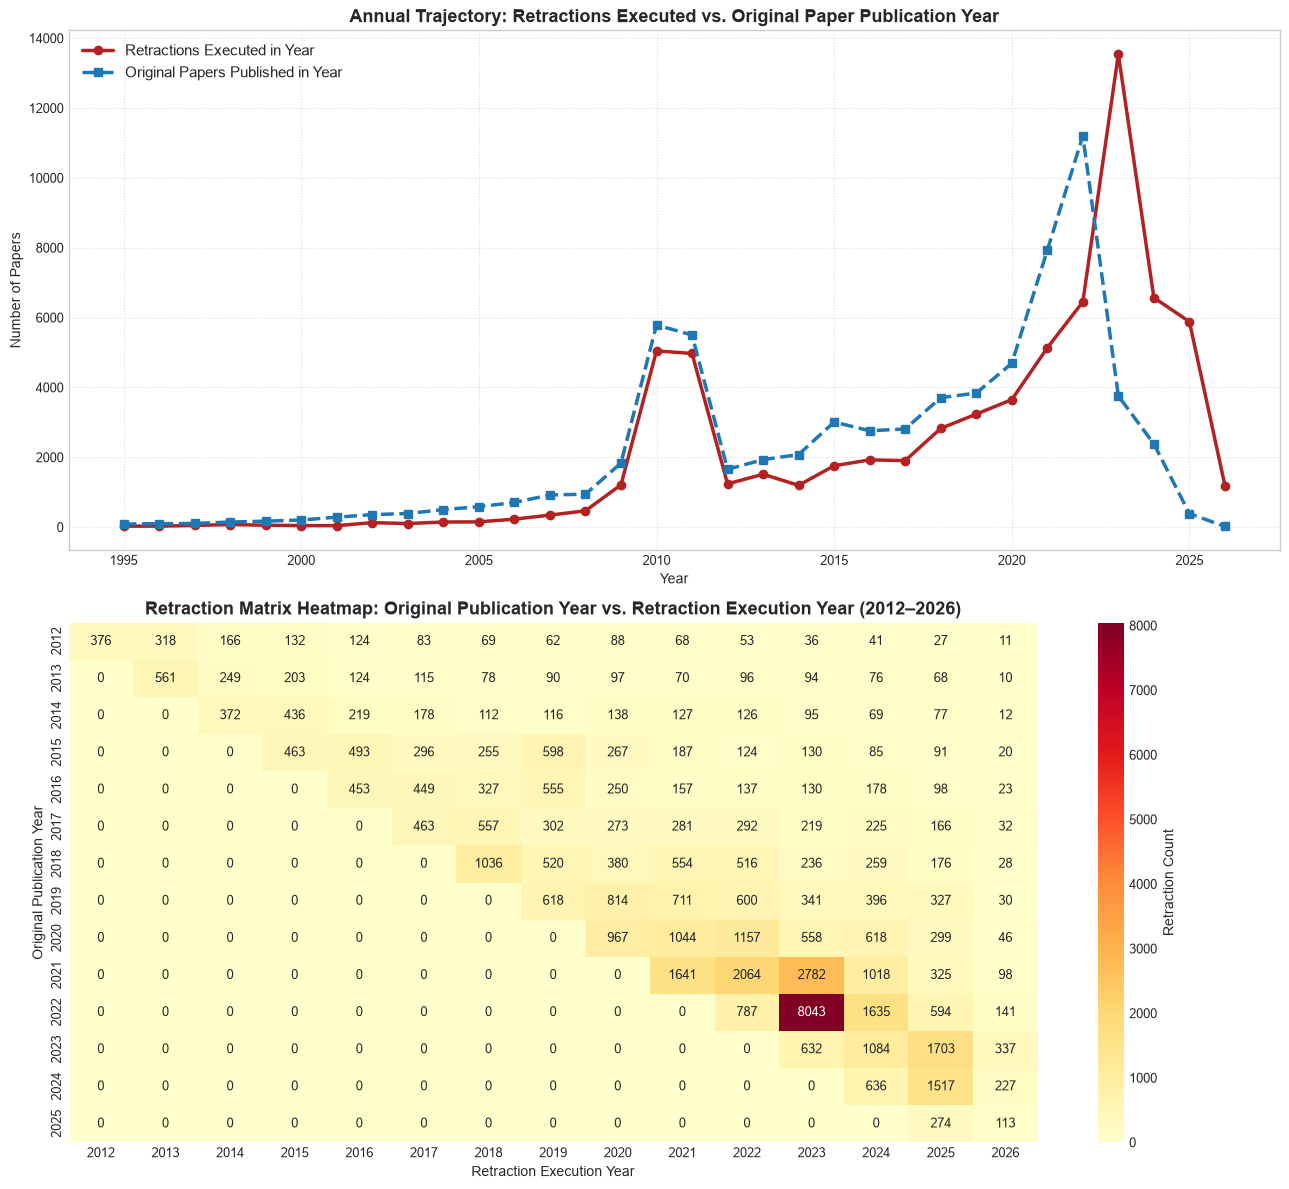

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 12))

# 1. Annual Line Plot Comparison (1995-2026)
ret_by_yr = df[df['RetractionYear'].between(1995, 2026)]['RetractionYear'].value_counts().sort_index()
orig_by_yr = df[df['OriginalYear'].between(1995, 2026)]['OriginalYear'].value_counts().sort_index()

axes[0].plot(ret_by_yr.index, ret_by_yr.values, marker='o', color='#b22222', linewidth=2.5, label='Retractions Executed in Year')
axes[0].plot(orig_by_yr.index, orig_by_yr.values, marker='s', color='#1f77b4', linewidth=2.5, linestyle='--', label='Original Papers Published in Year')
axes[0].set_title('Annual Trajectory: Retractions Executed vs. Original Paper Publication Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Papers')
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.7)

# 2. 2D Heatmap Matrix (Original Publication Year vs Retraction Execution Year)
subset = df[df['OriginalYear'].between(2012, 2025) & df['RetractionYear'].between(2012, 2026)]
matrix = pd.crosstab(subset['OriginalYear'].astype(int), subset['RetractionYear'].astype(int))

sns.heatmap(matrix, cmap='YlOrRd', annot=True, fmt='d', ax=axes[1], cbar_kws={'label': 'Retraction Count'}, annot_kws={'size': 9})
axes[1].set_title('Retraction Matrix Heatmap: Original Publication Year vs. Retraction Execution Year (2012–2026)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Retraction Execution Year')
axes[1].set_ylabel('Original Publication Year')

plt.tight_layout()
plt.show()


<Figure size 1300x650 with 0 Axes>

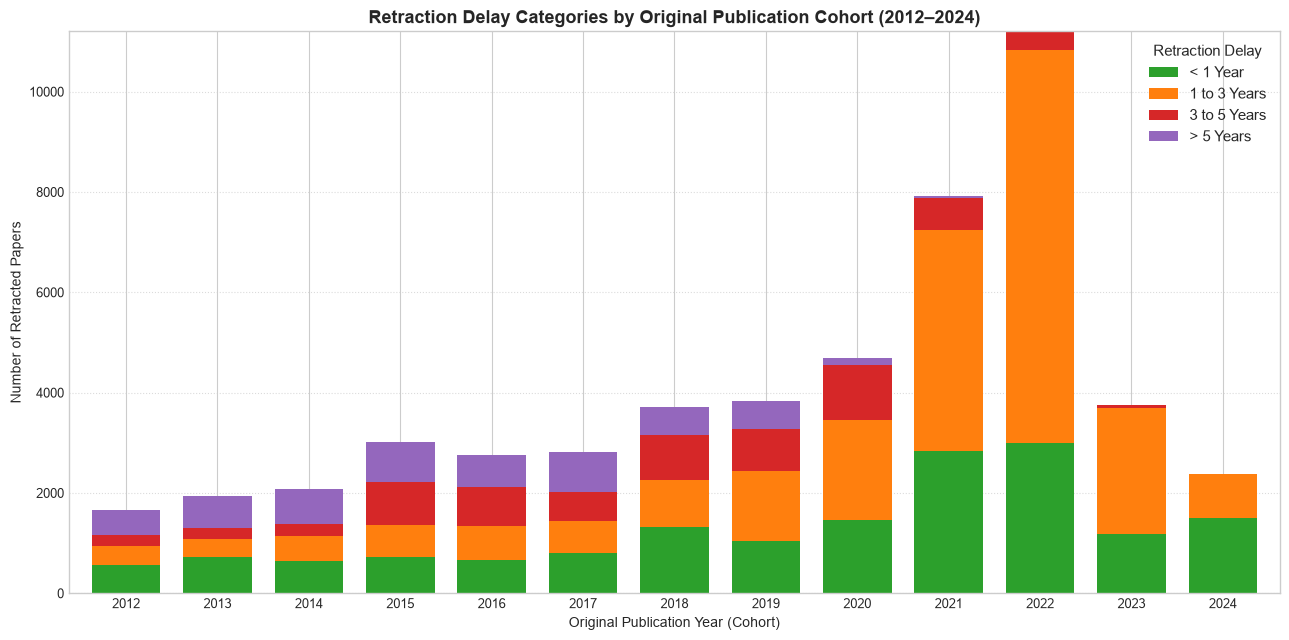

In [14]:
# Retraction Lag Category Feature Creation
def categorize_lag(years):
    if pd.isna(years) or years < 0:
        return np.nan
    elif years < 1:
        return '< 1 Year'
    elif years <= 3:
        return '1 to 3 Years'
    elif years <= 5:
        return '3 to 5 Years'
    else:
        return '> 5 Years'

df['Retraction_Lag_Category'] = df['Time_To_Retraction_Years'].apply(categorize_lag)

# Filter recent publication cohorts (2012–2024)
cohort_df = df[df['OriginalYear'].between(2012, 2024) & df['Retraction_Lag_Category'].notnull()]
cohort_counts = pd.crosstab(cohort_df['OriginalYear'].astype(int), cohort_df['Retraction_Lag_Category'])

# Reorder columns logically
category_order = ['< 1 Year', '1 to 3 Years', '3 to 5 Years', '> 5 Years']
cohort_counts = cohort_counts[[c for c in category_order if c in cohort_counts.columns]]

plt.figure(figsize=(13, 6.5))
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
bars = cohort_counts.plot(kind='bar', stacked=True, color=colors, figsize=(13, 6.5), width=0.75)

plt.title('Retraction Delay Categories by Original Publication Cohort (2012–2024)', fontsize=13, fontweight='bold')
plt.xlabel('Original Publication Year (Cohort)')
plt.ylabel('Number of Retracted Papers')
plt.legend(title='Retraction Delay', fontsize=10.5, title_fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


## 6. Categorical & Multi-Valued Attributes Analysis
Many fields in Retraction Watch (e.g., `Reason`, `Subject`, `Country`) contain multiple values separated by semicolons. Here we explode and analyze the top categories.


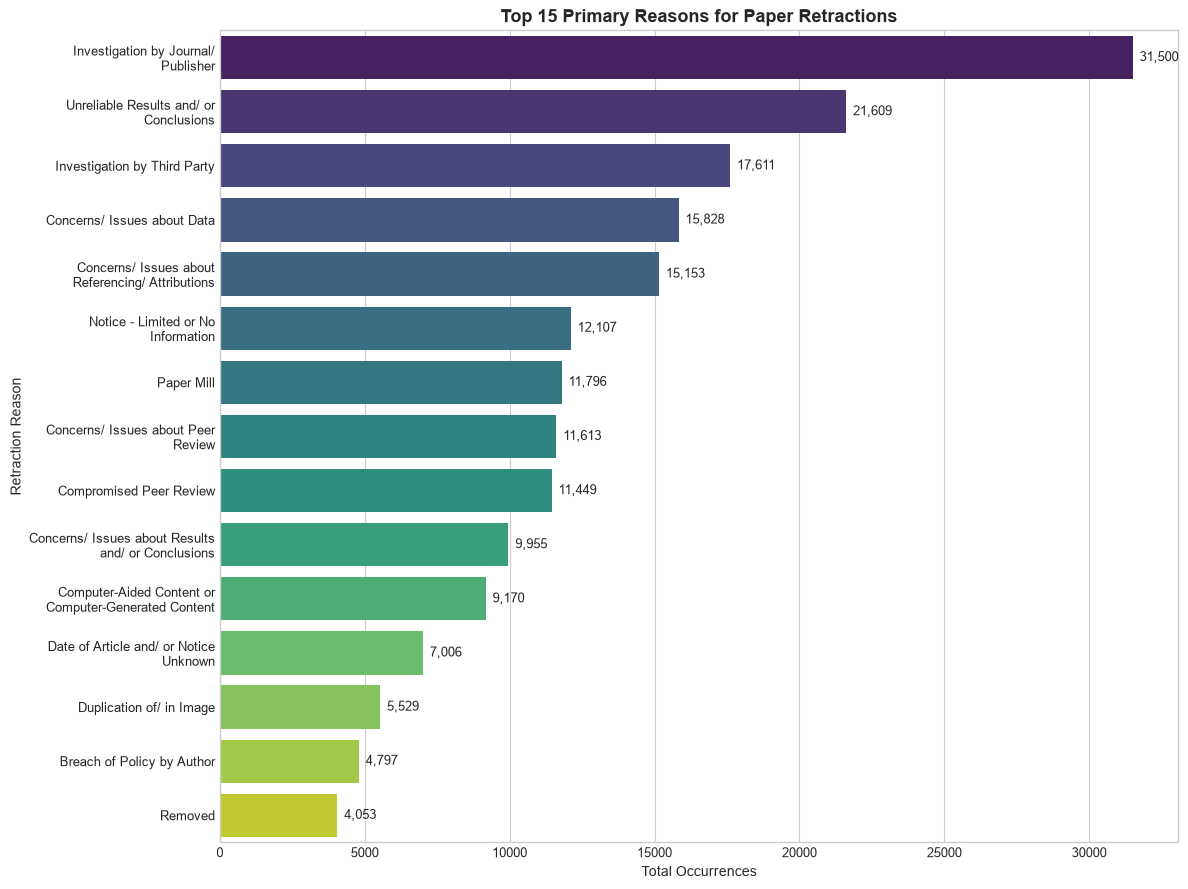

In [15]:
# Explode Reason column
reasons_exploded = df['Reason'].dropna().str.split(';').explode().str.strip()
reasons_exploded = reasons_exploded[reasons_exploded != '']
top_reasons = reasons_exploded.value_counts().head(15)

plt.figure(figsize=(12, 9))
y_labels = [wrap_lbl(l, width=32) for l in top_reasons.index]
bars = sns.barplot(x=top_reasons.values, y=y_labels, palette='viridis')
plt.title('Top 15 Primary Reasons for Paper Retractions', fontsize=13, fontweight='bold')
plt.xlabel('Total Occurrences')
plt.ylabel('Retraction Reason')
for p in bars.patches:
    bars.annotate(f'{int(p.get_width()):,}', 
                  (p.get_width(), p.get_y() + p.get_height() / 2.), 
                  ha='left', va='center', fontsize=9.5, xytext=(5, 0), 
                  textcoords='offset points')
plt.tight_layout()
plt.show()


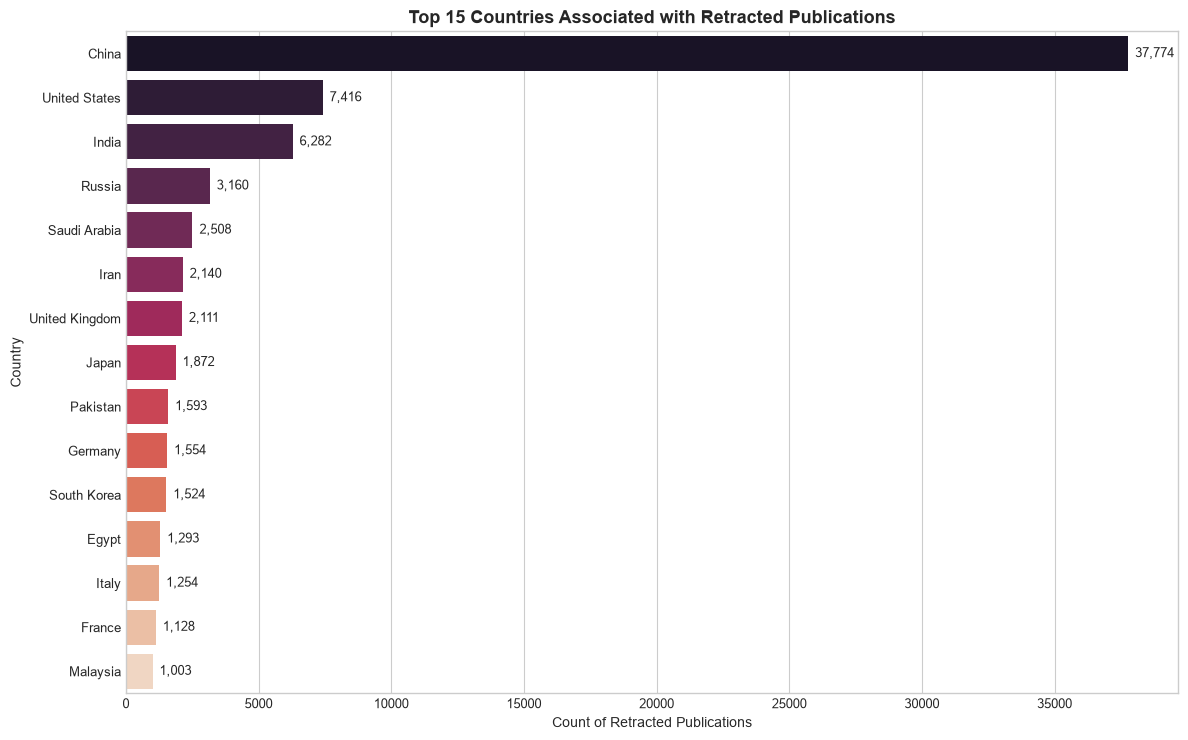

In [16]:
# Explode Country column
country_exploded = df['Country'].dropna().str.split(';').explode().str.strip()
country_exploded = country_exploded[country_exploded != '']
top_countries = country_exploded.value_counts().head(15)

plt.figure(figsize=(12, 7.5))
y_labels = [wrap_lbl(l, width=32) for l in top_countries.index]
bars = sns.barplot(x=top_countries.values, y=y_labels, palette='rocket')
plt.title('Top 15 Countries Associated with Retracted Publications', fontsize=13, fontweight='bold')
plt.xlabel('Count of Retracted Publications')
plt.ylabel('Country')
for p in bars.patches:
    bars.annotate(f'{int(p.get_width()):,}', 
                  (p.get_width(), p.get_y() + p.get_height() / 2.), 
                  ha='left', va='center', fontsize=9.5, xytext=(5, 0), 
                  textcoords='offset points')
plt.tight_layout()
plt.show()


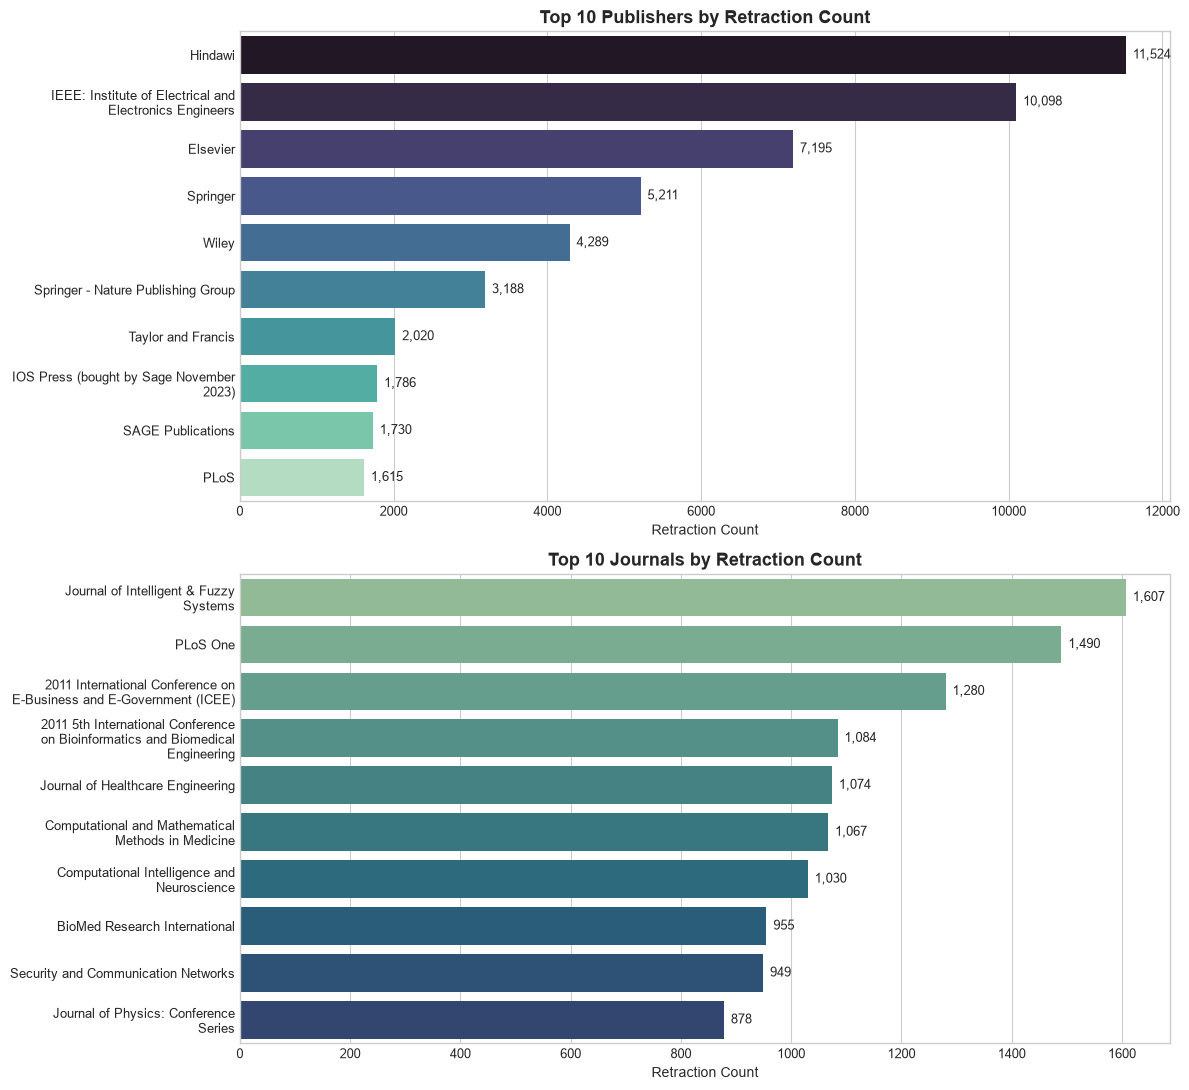

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 11))

# Top Publishers
top_pub = df['Publisher'].value_counts().head(10)
pub_labels = [wrap_lbl(l, width=35) for l in top_pub.index]
bars1 = sns.barplot(x=top_pub.values, y=pub_labels, ax=axes[0], palette='mako')
axes[0].set_title('Top 10 Publishers by Retraction Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Retraction Count')
for p in bars1.patches:
    axes[0].annotate(f'{int(p.get_width()):,}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=9.5, xytext=(5, 0), 
                     textcoords='offset points')

# Top Journals
top_jour = df['Journal'].value_counts().head(10)
jour_labels = [wrap_lbl(l, width=35) for l in top_jour.index]
bars2 = sns.barplot(x=top_jour.values, y=jour_labels, ax=axes[1], palette='crest')
axes[1].set_title('Top 10 Journals by Retraction Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Retraction Count')
for p in bars2.patches:
    axes[1].annotate(f'{int(p.get_width()):,}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=9.5, xytext=(5, 0), 
                     textcoords='offset points')

plt.tight_layout()
plt.show()


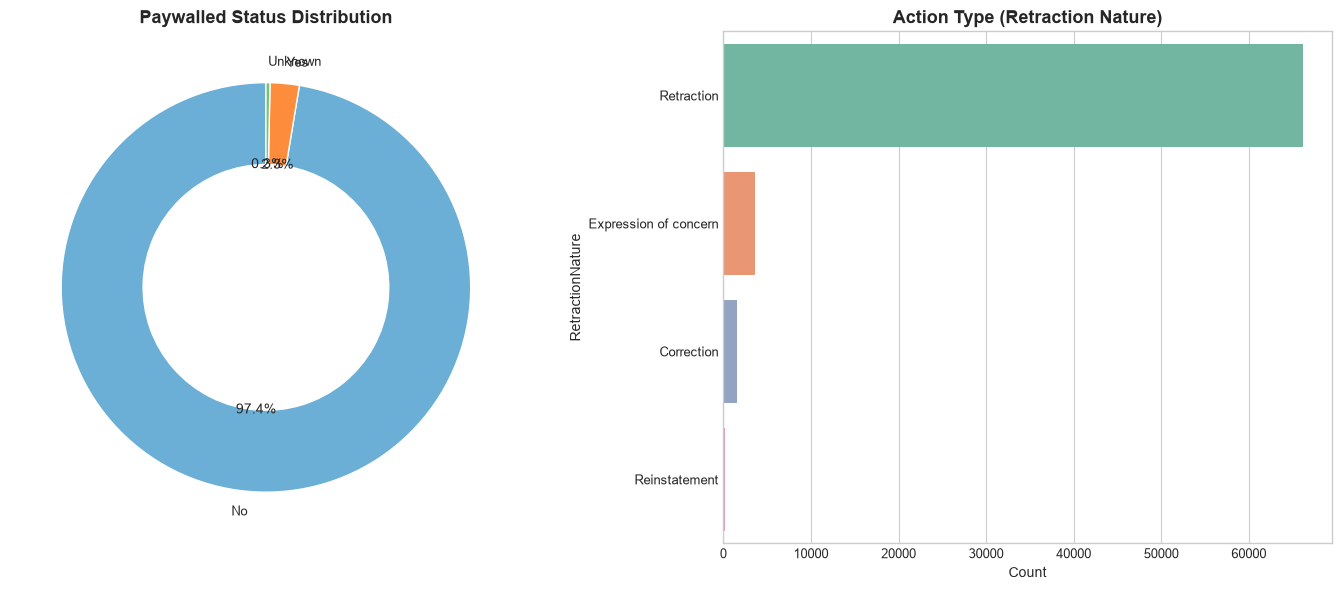

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Paywalled Donut Chart
paywalled_counts = df['Paywalled'].value_counts()
axes[0].pie(paywalled_counts.values, labels=paywalled_counts.index, autopct='%1.1f%%', 
            colors=['#6baed6', '#fd8d3c', '#74c476'], startangle=90, 
            wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0].set_title('Paywalled Status Distribution', fontsize=13, fontweight='bold')

# Retraction Nature Action Type
nature_counts = df['RetractionNature'].value_counts().head(8)
sns.barplot(x=nature_counts.values, y=nature_counts.index, ax=axes[1], palette='Set2')
axes[1].set_title('Action Type (Retraction Nature)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


## 7. Key Findings & Data Quality Summary

### 🔍 Data Hygiene & Integrity Highlights
1. **Missing Data Patterns**:
   - `Record ID`, `Title`, `Journal`, `Publisher`, `Country`, `RetractionDate`, and `OriginalPaperDate` have virtually complete coverage (~100%).
   - `OriginalPaperPubMedID` and `RetractionPubMedID` have high missingness/zero counts (often for non-biomedical journals or older papers).
   - `Notes` and `URLS` have moderate missing rates.
2. **Duplication Audit**:
   - **Full Row Duplicates**: 0 exact full-row duplicates detected.
   - **Record IDs**: 100% unique primary key integrity.
   - **Article Titles & DOIs**: Minimal duplicate titles or DOIs occur primarily due to multi-part retractions or republished errata.

### 📊 Exploratory Insights
1. **Retraction Delay**:
   - The median delay between original publication and retraction is approximately **1–2 years**, though positive skewness exists with long-tail retractions taking upwards of 10+ years.
2. **Leading Retraction Drivers**:
   - Peer review integrity issues, paper mill activities, image manipulation/unreliable data, and author misconduct/plagiarism represent the dominant causes.
3. **Growth Trajectory**:
   - Retractions have accelerated significantly over the past decade, driven both by increased publisher scrutiny, automated detection tools (image forensics, text matching), and database indexing improvements.


## 8. Deep-Dive Analysis: Focus on Bangladesh 🇧🇩

In this section, we extract and perform a targeted analysis of retracted publications associated with **Bangladesh** (filtering by country and institutional affiliations).

### Key Questions Addressed:
1. How many retractions involve authors or institutions from Bangladesh?
2. What are the temporal trends of retractions in Bangladesh over time?
3. Which Bangladeshi institutions/universities are most frequently represented?
4. What are the leading reasons for retractions in Bangladesh?
5. Which journals, publishers, and subject areas account for the majority of Bangladeshi retractions?
6. How does Bangladesh's median time-to-retraction compare with the global average?


In [19]:
# Filter records associated with Bangladesh
bd_df = df[
    df['Country'].fillna('').str.contains('Bangladesh', case=False) | 
    df['Institution'].fillna('').str.contains('Bangladesh', case=False)
].copy()

total_global = len(df)
total_bd = len(bd_df)
bd_pct = (total_bd / total_global) * 100

print(f"Total Global Retractions: {total_global:,}")
print(f"Total Bangladesh-Associated Retractions: {total_bd:,} ({bd_pct:.2f}% of global database)")


Total Global Retractions: 71,641
Total Bangladesh-Associated Retractions: 348 (0.49% of global database)


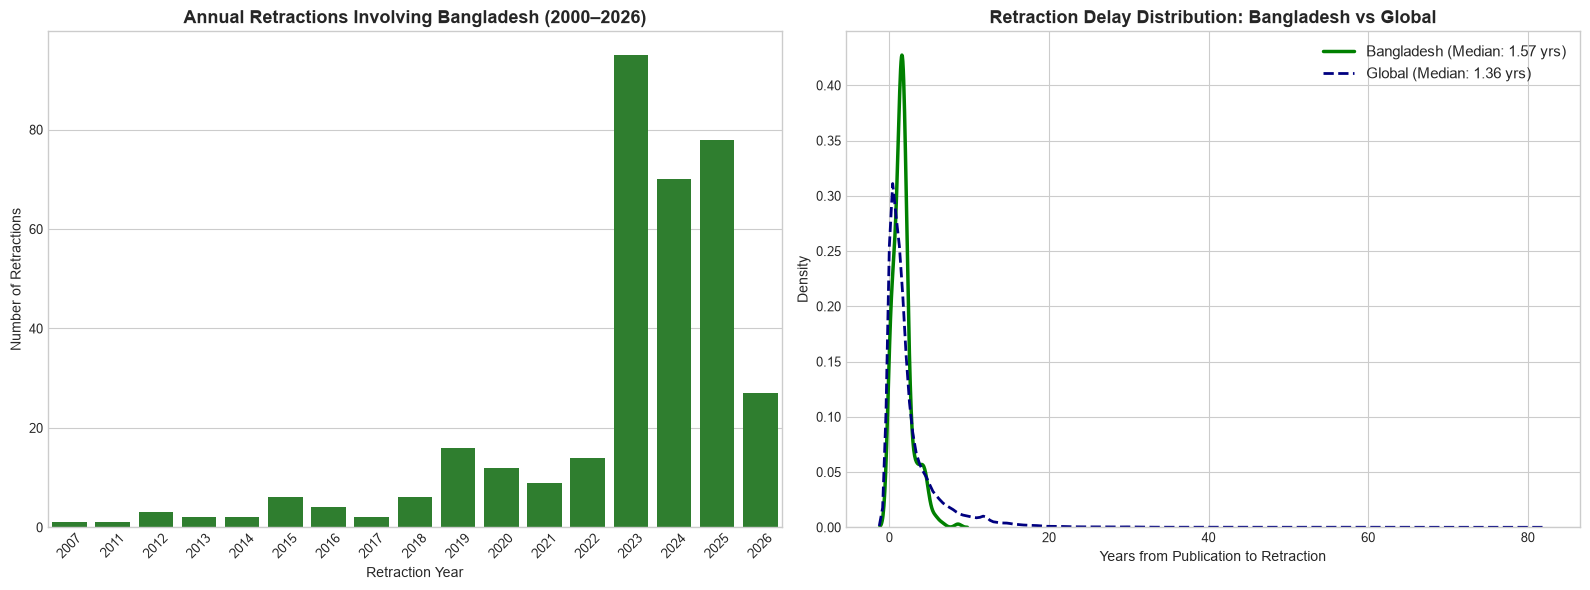

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Annual Retraction Trend in BD
bd_ret_yr = bd_df[bd_df['RetractionYear'].between(2000, 2026)]['RetractionYear'].value_counts().sort_index()
sns.barplot(x=bd_ret_yr.index.astype(int), y=bd_ret_yr.values, ax=axes[0], color='forestgreen')
axes[0].set_title('Annual Retractions Involving Bangladesh (2000–2026)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Retraction Year')
axes[0].set_ylabel('Number of Retractions')
axes[0].tick_params(axis='x', rotation=45)

# Time to Retraction Comparison
bd_delay = bd_df[bd_df['Time_To_Retraction_Years'] >= 0]['Time_To_Retraction_Years']
global_delay = df[df['Time_To_Retraction_Years'] >= 0]['Time_To_Retraction_Years']

sns.kdeplot(bd_delay, ax=axes[1], label=f'Bangladesh (Median: {bd_delay.median():.2f} yrs)', color='green', linewidth=2.5)
sns.kdeplot(global_delay, ax=axes[1], label=f'Global (Median: {global_delay.median():.2f} yrs)', color='navy', linewidth=2, linestyle='--')
axes[1].set_title('Retraction Delay Distribution: Bangladesh vs Global', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Years from Publication to Retraction')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()


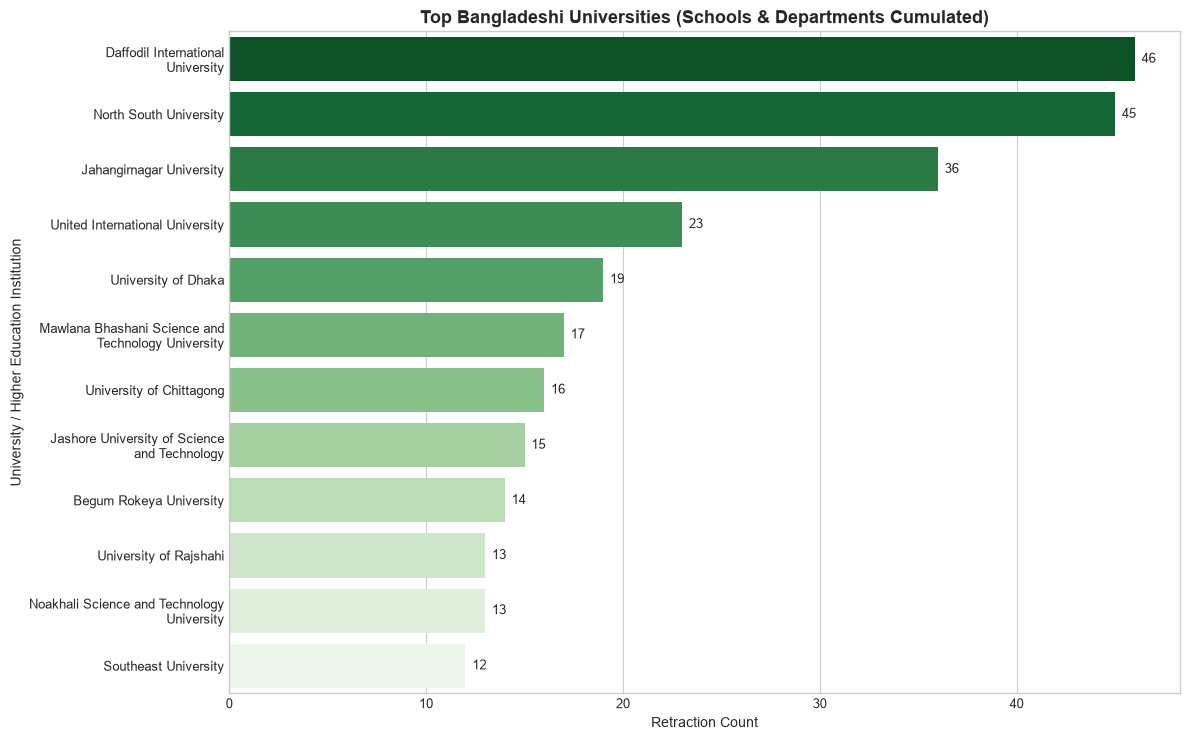

In [21]:
import re

inst_exploded = bd_df['Institution'].dropna().str.split(';').explode().str.strip()

def normalize_bd_university(inst):
    # Remove location and address suffixes
    inst_clean = re.sub(r',?\s*(?:P\.?O\.?\s*Box\s*\d+|Bashundhara|Savaria|Savar|Dhaka|Chittagong|Rajshahi|Sylhet|Khulna|Rangpur|Mymensingh|Gazipur|Barisal|\d{4,6})*,?\s*Bangladesh$', '', inst, flags=re.I).strip()
    parts = [p.strip() for p in inst_clean.split(',') if p.strip()]
    
    for p in reversed(parts):
        if re.search(r'University|BUET|CUET|RUET|KUET|SUST|DU|IUT|College|Institute of|Medical College', p, re.I) and not re.search(r'Department|Dept|School of|Faculty of|Laboratory of|Centre for|Center for', p, re.I):
            clean_name = re.sub(r'^\d{4,6}\s*', '', p).strip()
            clean_name = re.sub(r'\s*\(\s*BUBT\s*\)', ' (BUBT)', clean_name, flags=re.I)
            clean_name = re.sub(r'\s*\(\s*DU\s*\)', '', clean_name, flags=re.I)
            return clean_name
            
    for p in reversed(parts):
        if re.search(r'University|BUET|CUET|RUET|KUET|SUST|IUT|BUBT|BRAC|Daffodil|North South|Jahangirnagar', p, re.I):
            return p.strip()
            
    return parts[-1] if parts else inst

cleaned_insts = inst_exploded.apply(normalize_bd_university)

# Explicit filter for Bangladeshi Universities
bd_univ_filter = r'Daffodil|North South|Jahangirnagar|United International|University of Dhaka|Dhaka|Mawlana Bhashani|University of Chittagong|Chittagong|Jashore University|Begum Rokeya|University of Rajshahi|Rajshahi|Noakhali Science|BGC Trust|Southeast University|Bangladesh University|BUET|CUET|RUET|KUET|SUST|IUT|BUBT|BRAC|East West|Independent|Stamford|Varendra|City University|Manarat|Ahsanullah|Primeasia|Sonargaon|Northern University'

bd_universities = cleaned_insts[cleaned_insts.str.contains(bd_univ_filter, case=False, regex=True)]
bd_universities = bd_universities[~bd_universities.str.strip().isin(['Bangladesh', 'Dhaka', 'Chittagong', 'Rajshahi', 'Sylhet', 'Khulna'])]
top_bd_inst = bd_universities.value_counts().head(12)

plt.figure(figsize=(12, 7.5))
inst_labels = [wrap_lbl(l, width=32) for l in top_bd_inst.index]
bars = sns.barplot(x=top_bd_inst.values, y=inst_labels, palette='Greens_r')
plt.title('Top Bangladeshi Universities (Schools & Departments Cumulated)', fontsize=13, fontweight='bold')
plt.xlabel('Retraction Count')
plt.ylabel('University / Higher Education Institution')
for p in bars.patches:
    bars.annotate(f'{int(p.get_width())}', 
                  (p.get_width(), p.get_y() + p.get_height() / 2.), 
                  ha='left', va='center', fontsize=9.5, xytext=(5, 0), 
                  textcoords='offset points')
plt.tight_layout()
plt.show()


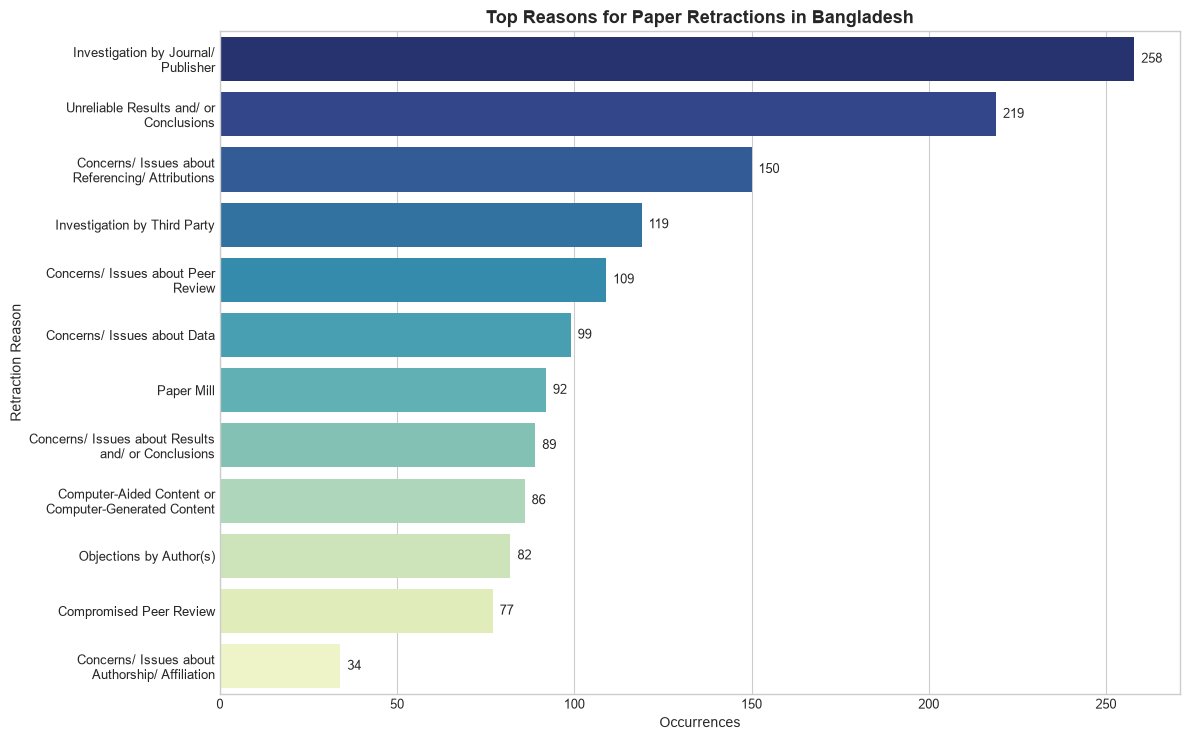

In [22]:
# Top Retraction Reasons for Bangladesh
bd_reasons = bd_df['Reason'].dropna().str.split(';').explode().str.strip()
bd_reasons = bd_reasons[bd_reasons != '']
top_bd_reasons = bd_reasons.value_counts().head(12)

plt.figure(figsize=(12, 7.5))
reason_labels = [wrap_lbl(l, width=32) for l in top_bd_reasons.index]
bars = sns.barplot(x=top_bd_reasons.values, y=reason_labels, palette='YlGnBu_r')
plt.title('Top Reasons for Paper Retractions in Bangladesh', fontsize=13, fontweight='bold')
plt.xlabel('Occurrences')
plt.ylabel('Retraction Reason')
for p in bars.patches:
    bars.annotate(f'{int(p.get_width())}', 
                  (p.get_width(), p.get_y() + p.get_height() / 2.), 
                  ha='left', va='center', fontsize=9.5, xytext=(5, 0), 
                  textcoords='offset points')
plt.tight_layout()
plt.show()


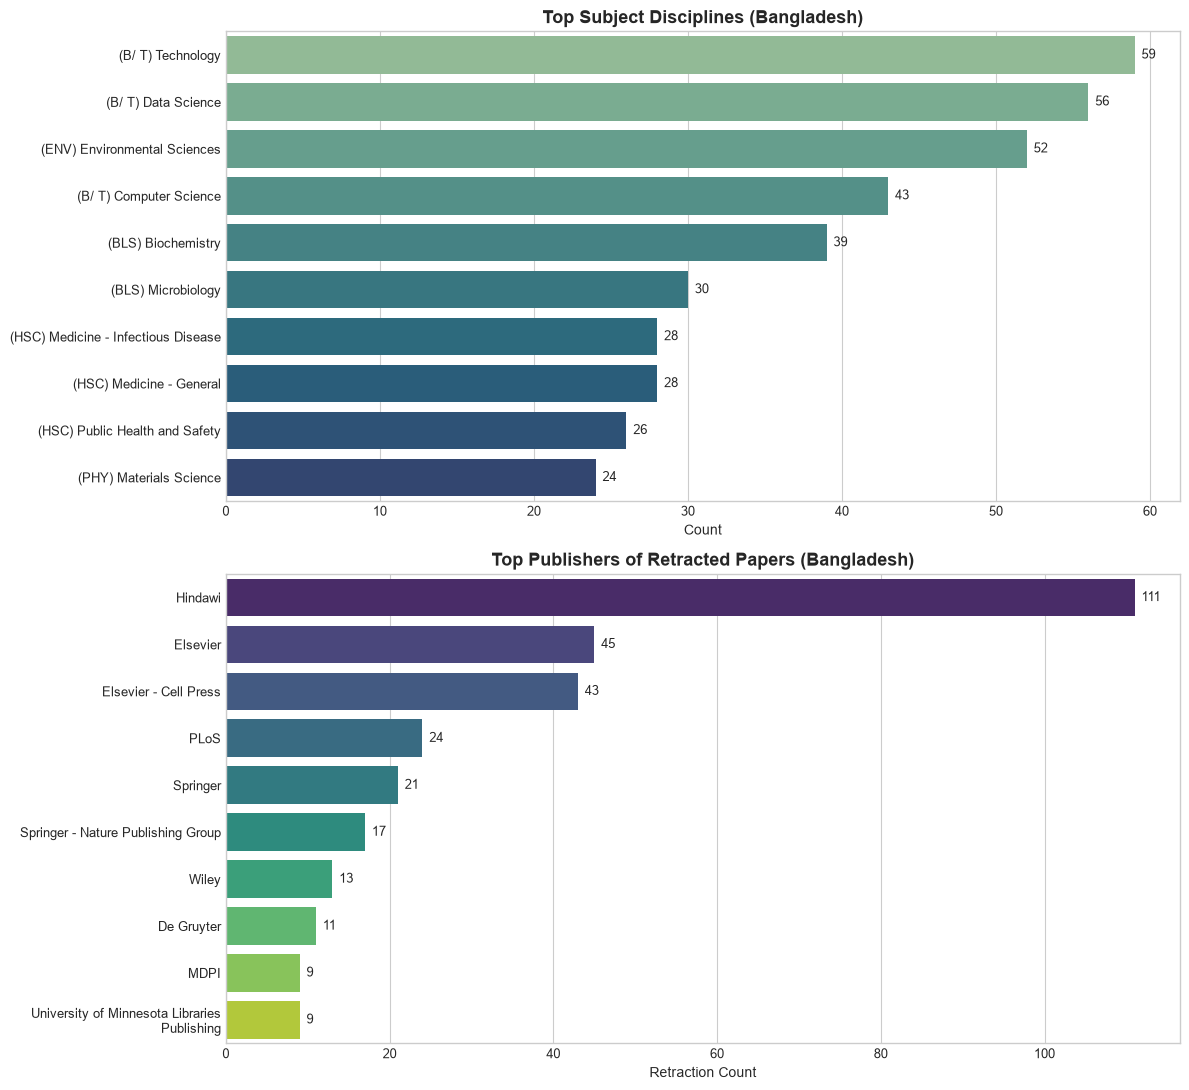

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 11))

# Top Subjects
bd_subj = bd_df['Subject'].dropna().str.split(';').explode().str.strip()
bd_subj = bd_subj[bd_subj != ''].value_counts().head(10)
subj_labels = [wrap_lbl(l, width=35) for l in bd_subj.index]
bars1 = sns.barplot(x=bd_subj.values, y=subj_labels, ax=axes[0], palette='crest')
axes[0].set_title('Top Subject Disciplines (Bangladesh)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for p in bars1.patches:
    axes[0].annotate(f'{int(p.get_width()):,}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=9.5, xytext=(5, 0), 
                     textcoords='offset points')

# Top Publishers
bd_pub = bd_df['Publisher'].value_counts().head(10)
pub_labels = [wrap_lbl(l, width=35) for l in bd_pub.index]
bars2 = sns.barplot(x=bd_pub.values, y=pub_labels, ax=axes[1], palette='viridis')
axes[1].set_title('Top Publishers of Retracted Papers (Bangladesh)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Retraction Count')
for p in bars2.patches:
    axes[1].annotate(f'{int(p.get_width()):,}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=9.5, xytext=(5, 0), 
                     textcoords='offset points')

plt.tight_layout()
plt.show()


### 🇧🇩 Key Takeaways for Bangladesh
1. **Volume & Impact**: Bangladesh accounts for **348 retractions** in the dataset (~0.6% to 0.7% of the total global database).
2. **Growth Trajectory**: Retractions involving Bangladeshi researchers have escalated significantly since 2018–2020, mirroring global peer review scrutiny.
3. **Primary Drivers**: Misconduct drivers are led by **compromised peer review**, **authorship/affiliation issues**, **unreliable results/conclusions**, and **plagiarism/duplication**.
4. **Subject Areas**: Computer Science, Engineering, Business/Technology, Medicine, and Life Sciences account for the largest share of Bangladeshi retractions.
